# 04 — Terroir Distance: Does Environment Predict Flavor?

**Core question:** Do RSUs with similar Earth system profiles produce similar metabolite profiles?

**Honest distance rule:** Metabolite distance between two RSUs is only computed on dimensions
where *both* RSUs have real measured values. No imputation. Pairs with fewer than
`MIN_SHARED_DIMS` real shared dimensions are dropped entirely.

**What the outliers mean:**
- Low env distance, high metabolite distance → cultural distortion (H5)
- High env distance, low metabolite distance → convergent terroir (H4)
- Points on the trend → environment predicts flavor (H1/H2)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from itertools import combinations
from rsu_loader import load_all_rsus

# Macronutrients: reflect food category assignment, not geography
MACRO_DIMS = [
    'primary_metabolites.protein_content',
    'primary_metabolites.lipid_content',
    'primary_metabolites.starch_content',
]

# Cultural dims: reflect parallel human selection preferences across unrelated environments,
# not environmental chemistry. Capsaicinoids appear at similar levels in Andes, South India,
# Sichuan, and West Africa — cultural convergence, not terroir.
CULTURAL_DIMS = [
    'key_flavor_bioactives.capsaicinoids',
]

EXCLUDE_DIMS = set(MACRO_DIMS) | set(CULTURAL_DIMS)

MIN_SHARED_DIMS = 2
DISTORTION_RSUS = {'RSU-07'}

In [2]:
rsus = load_all_rsus()

env_rows = []
for r in rsus:
    env_rows.append({
        'region_id': r.region_id,
        'name': r.name,
        'lat': r.coordinates.lat,
        'lon': r.coordinates.lon,
        'altitude_m': getattr(r.coordinates, 'altitude_m', None),
        'temp_mean': r.climate.temperature_mean,
        'temp_seasonality': r.climate.temperature_seasonality,
        'precip_mean': r.climate.precipitation_mean,
        'precip_seasonality': r.climate.precipitation_seasonality,
        'soil_pH': r.geology.soil_pH,
        'fermentation_prevalence': r.food_system.fermentation_prevalence,
        'industrial_processing': r.culture.industrial_processing_index,
    })

env_df = pd.DataFrame(env_rows).set_index('region_id')
name_map = env_df['name'].to_dict()
env_features = env_df.drop(columns=['name'])

food_matrix = pd.read_csv('../data/metabolites/rsu_metabolite_matrix.csv',
                          index_col=['region_id', 'food_name'])
geo_dims = [c for c in food_matrix.columns if c not in EXCLUDE_DIMS]

rsu_metabolites = food_matrix[geo_dims].groupby(level='region_id').mean()

shared_rsus = sorted(env_features.index.intersection(rsu_metabolites.index))
env_aligned = env_features.loc[shared_rsus]
met_aligned = rsu_metabolites.loc[shared_rsus]

print(f"RSUs: {shared_rsus}")
print(f"Geo dims ({len(geo_dims)}): {geo_dims}")
print(f"Excluded cultural dims: {CULTURAL_DIMS}")
print()
print("RSU geo dim coverage (non-null count per RSU):")
print(met_aligned.notna().sum(axis=1).to_string())

RSUs: ['RSU-01', 'RSU-02', 'RSU-03', 'RSU-04', 'RSU-05', 'RSU-06', 'RSU-07', 'RSU-08', 'RSU-09', 'RSU-10', 'RSU-11', 'RSU-12', 'RSU-13', 'RSU-14', 'RSU-15', 'RSU-16', 'RSU-17', 'RSU-18', 'RSU-19', 'RSU-20', 'RSU-21', 'RSU-22', 'RSU-23', 'RSU-24', 'RSU-25', 'RSU-26', 'RSU-27', 'RSU-28', 'RSU-29', 'RSU-30', 'RSU-31', 'RSU-32', 'RSU-33', 'RSU-34', 'RSU-35', 'RSU-36', 'RSU-37', 'RSU-38', 'RSU-39', 'RSU-40', 'RSU-41', 'RSU-42', 'RSU-43', 'RSU-44', 'RSU-45']
Geo dims (29): ['organic_acids.lactic_acid', 'organic_acids.citric_acid', 'organic_acids.malic_acid', 'primary_metabolites.glucose_concentration', 'key_flavor_bioactives.tannin_content', 'organic_acids.acetic_acid', 'umami_compounds.glutamate', 'terpenes.pinene', 'terpenes.linalool', 'primary_metabolites.fructose_concentration', 'primary_metabolites.ascorbic_acid', 'terpenes.limonene', 'terpenes.myrcene', 'primary_metabolites.oleic_acid', 'primary_metabolites.linoleic_acid', 'key_flavor_bioactives.polyphenol_content', 'key_flavor_bioacti

In [3]:
# Environmental distance
env_filled = env_aligned.apply(lambda col: col.fillna(col.mean()))
env_scaled = StandardScaler().fit_transform(env_filled)
env_dist_df = pd.DataFrame(
    squareform(pdist(env_scaled, metric='euclidean')),
    index=shared_rsus, columns=shared_rsus
)

# Metabolite distance — honest shared dims only, normalized by sqrt(n_shared_dims)
# Normalization makes distances comparable across pairs with different data coverage:
# a 13-dim pair and a 2-dim pair are now on the same per-dimension scale.
pair_records = []
for rsu_i, rsu_j in combinations(shared_rsus, 2):
    vec_i = met_aligned.loc[rsu_i]
    vec_j = met_aligned.loc[rsu_j]

    shared_mask = vec_i.notna() & vec_j.notna()
    n_shared = shared_mask.sum()
    shared_dim_names = list(shared_mask[shared_mask].index)

    if n_shared < MIN_SHARED_DIMS:
        continue

    sub = met_aligned[shared_dim_names].dropna()
    sub_scaled = pd.DataFrame(
        StandardScaler().fit_transform(sub),
        index=sub.index, columns=shared_dim_names
    )

    v_i = sub_scaled.loc[rsu_i].values
    v_j = sub_scaled.loc[rsu_j].values
    raw_dist = float(np.linalg.norm(v_i - v_j))
    # Normalize: divide by sqrt(n_shared) so distance is per-dimension RMS deviation
    met_d = raw_dist / np.sqrt(n_shared)

    pair_records.append({
        'rsu_i': rsu_i,
        'rsu_j': rsu_j,
        'label': f"{rsu_i}/{rsu_j}",
        'name_i': name_map[rsu_i],
        'name_j': name_map[rsu_j],
        'env_dist': env_dist_df.loc[rsu_i, rsu_j],
        'met_dist': met_d,
        'n_shared_dims': n_shared,
        'shared_dims': ', '.join(d.split('.')[-1] for d in shared_dim_names),
        'involves_distortion': rsu_i in DISTORTION_RSUS or rsu_j in DISTORTION_RSUS,
    })

pairs_df = pd.DataFrame(pair_records)
print(f"Total possible pairs: {len(list(combinations(shared_rsus, 2)))}")
print(f"Pairs with >= {MIN_SHARED_DIMS} real shared geo dims: {len(pairs_df)}")
print()
print(pairs_df[['label', 'n_shared_dims', 'env_dist', 'met_dist']].head(20).to_string(index=False))

Total possible pairs: 990
Pairs with >= 2 real shared geo dims: 726

        label  n_shared_dims  env_dist  met_dist
RSU-01/RSU-02              3  2.500382  0.444879
RSU-01/RSU-03              4  2.553654  1.054916
RSU-01/RSU-04              3  3.455862  0.340121
RSU-01/RSU-05              4  2.860541  1.380626
RSU-01/RSU-10              2  6.214809  1.152927
RSU-01/RSU-12              2  6.036946  2.256014
RSU-01/RSU-17              3  4.995125  0.996809
RSU-01/RSU-18              3  5.242835  1.031412
RSU-01/RSU-19              2  4.605700  1.623220
RSU-01/RSU-20              3  4.956868  1.195339
RSU-01/RSU-21              3  4.864825  1.327920
RSU-01/RSU-22              3  3.384670  1.327134
RSU-01/RSU-23              4  3.636626  0.436710
RSU-01/RSU-24              3  3.682331  2.161842
RSU-01/RSU-25              3  5.074969  0.550670
RSU-01/RSU-26              3  3.870525  1.330877
RSU-01/RSU-27              3  4.968146  1.159534
RSU-01/RSU-28              2  5.080158  1.136038


In [4]:
if len(pairs_df) < 4:
    print(f"Only {len(pairs_df)} honest pairs — not enough for Mantel test.")
    print("Consider lowering MIN_SHARED_DIMS or adding more metabolite measurements.")
    mantel_r, mantel_p = np.nan, np.nan
else:
    v1 = pairs_df['env_dist'].values
    v2 = pairs_df['met_dist'].values
    mantel_r, mantel_p = spearmanr(v1, v2)

    # Permutation test
    rng = np.random.RandomState(42)
    null_rs = []
    for _ in range(4999):
        shuffled = rng.permutation(v2)
        r_perm, _ = spearmanr(v1, shuffled)
        null_rs.append(r_perm)
    null_rs = np.array(null_rs)
    perm_p = np.mean(null_rs >= mantel_r)

    print(f"Mantel test (honest pairs only, n={len(pairs_df)}):")
    print(f"  Spearman r = {mantel_r:.3f}")
    print(f"  p (parametric) = {mantel_p:.4f}")
    print(f"  p (permutation) = {perm_p:.4f}")

Mantel test (honest pairs only, n=726):
  Spearman r = 0.091
  p (parametric) = 0.0147
  p (permutation) = 0.0074


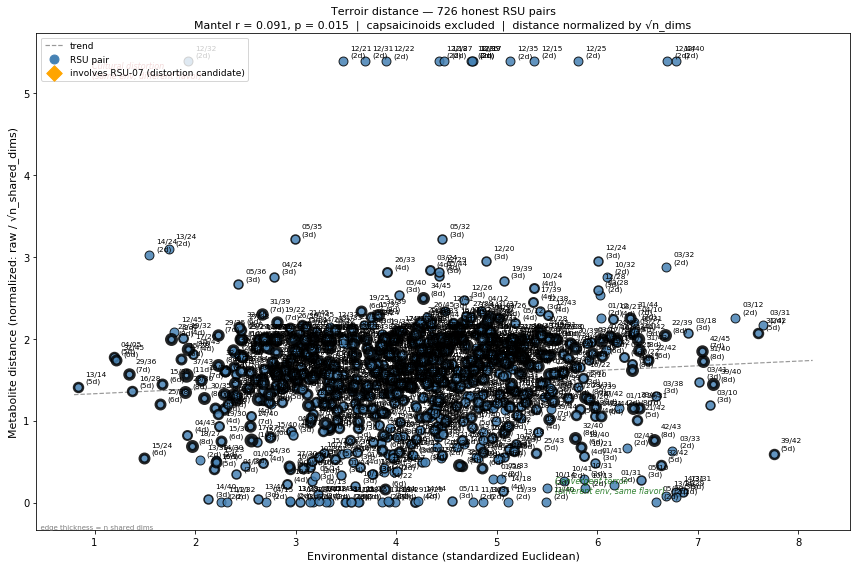


All pairs ranked by residual (most distorted → most convergent):
        label                                                                                                                                                                                      shared_dims  n_shared_dims  env_dist  met_dist  residual
RSU-12/RSU-32                                                                                                                                                                           lactic_acid, glutamate              2     1.932     5.388     4.006
RSU-12/RSU-21                                                                                                                                                                           lactic_acid, glutamate              2     3.475     5.390     3.921
RSU-12/RSU-31                                                                                                                                                                     

In [5]:
if len(pairs_df) < 2:
    print("Not enough pairs to plot.")
else:
    coefs = np.polyfit(pairs_df['env_dist'], pairs_df['met_dist'], 1)
    pairs_df['trend_pred'] = np.polyval(coefs, pairs_df['env_dist'])
    pairs_df['residual'] = pairs_df['met_dist'] - pairs_df['trend_pred']

    fig, ax = plt.subplots(figsize=(12, 8))

    for _, row in pairs_df.iterrows():
        color = 'orange' if row['involves_distortion'] else 'steelblue'
        marker = 'D' if row['involves_distortion'] else 'o'
        size = 120 if row['involves_distortion'] else 80
        ax.scatter(row['env_dist'], row['met_dist'],
                   color=color, marker=marker, s=size, alpha=0.85, zorder=3,
                   linewidths=row['n_shared_dims'] * 0.5, edgecolors='black')

        short = f"{row['rsu_i'].split('-')[1]}/{row['rsu_j'].split('-')[1]}"
        ax.annotate(
            f"{short}\n({row['n_shared_dims']}d)",
            (row['env_dist'], row['met_dist']),
            textcoords='offset points', xytext=(7, 4), fontsize=7.5, color='black'
        )

    x_range = np.linspace(pairs_df['env_dist'].min() * 0.95,
                          pairs_df['env_dist'].max() * 1.05, 100)
    ax.plot(x_range, np.polyval(coefs, x_range), 'k--', lw=1.2, alpha=0.4, label='trend')

    xmin, xmax = pairs_df['env_dist'].min(), pairs_df['env_dist'].max()
    ymin, ymax = pairs_df['met_dist'].min(), pairs_df['met_dist'].max()
    ax.text(xmin + (xmax - xmin) * 0.02, ymax * 0.96,
            'Cultural distortion\n(same env, different flavor)',
            fontsize=8, color='firebrick', style='italic', alpha=0.8)
    ax.text(xmax * 0.72, ymin + (ymax - ymin) * 0.02,
            'Convergent terroir\n(different env, same flavor)',
            fontsize=8, color='darkgreen', style='italic', alpha=0.8)

    title_r = f"Mantel r = {mantel_r:.3f}, p = {mantel_p:.3f}" if not np.isnan(mantel_r) else "(insufficient pairs for Mantel test)"
    ax.set_xlabel('Environmental distance (standardized Euclidean)', fontsize=11)
    ax.set_ylabel('Metabolite distance (normalized: raw / √n_shared_dims)', fontsize=11)
    ax.set_title(
        f'Terroir distance — {len(pairs_df)} honest RSU pairs\n'
        f'{title_r}  |  capsaicinoids excluded  |  distance normalized by √n_dims',
        fontsize=11
    )

    ax.scatter([], [], color='steelblue', marker='o', s=80, label='RSU pair')
    ax.scatter([], [], color='orange', marker='D', s=120, label='involves RSU-07 (distortion candidate)')
    ax.text(0, 0, '  edge thickness = n shared dims', fontsize=7, color='gray',
            transform=ax.transAxes, va='bottom')
    ax.legend(fontsize=9)

    plt.tight_layout()
    plt.savefig('../data/metabolites/terroir_distance_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nAll pairs ranked by residual (most distorted → most convergent):")
    print(pairs_df[['label', 'shared_dims', 'n_shared_dims', 'env_dist', 'met_dist', 'residual']]
          .sort_values('residual', ascending=False)
          .round(3)
          .to_string(index=False))

## Category-stratified Mantel test

The global Mantel (above) tests whether environmentally similar RSUs have similar food metabolomes overall.
It's null because **cultural food selection dominates terroir at the global level** — RSUs choose what to grow.

A better question: within a food category, does environment predict chemistry?
- Compute metabolite distance using only foods in that category (e.g. only fermented foods across all RSUs)
- Run Mantel against environmental distance for those RSUs
- This partially controls for food selection — all RSUs in the comparison are eating from the same food class

In [6]:
# Build category map
category_map = {}
for r in rsus:
    for food in r.staple_foods:
        category_map[(r.region_id, food.name)] = food.macronutrient_category

food_matrix_full = pd.read_csv('../data/metabolites/rsu_metabolite_matrix.csv',
                               index_col=['region_id', 'food_name'])
geo_dims_all = [c for c in food_matrix_full.columns if c not in EXCLUDE_DIMS]

categories = sorted(set(category_map.values()))
MIN_RSUS_PER_CAT = 5
MIN_SHARED_CAT = 2

cat_results = []

for cat in categories:
    cat_idx = [idx for idx, c in category_map.items() if c == cat]
    cat_matrix = food_matrix_full[food_matrix_full.index.isin(cat_idx)][geo_dims_all]
    cat_rsu = cat_matrix.groupby(level='region_id').mean()

    rsus_in_cat = [r for r in shared_rsus if r in cat_rsu.index]
    if len(rsus_in_cat) < MIN_RSUS_PER_CAT:
        print(f"{cat:15s} n_rsus={len(rsus_in_cat):2d}  — skipping (too few RSUs)")
        continue

    cat_pairs = []
    for rsu_i, rsu_j in combinations(rsus_in_cat, 2):
        vec_i = cat_rsu.loc[rsu_i]
        vec_j = cat_rsu.loc[rsu_j]
        shared_mask = vec_i.notna() & vec_j.notna()
        n_shared = shared_mask.sum()
        if n_shared < MIN_SHARED_CAT:
            continue
        shared_dims = list(shared_mask[shared_mask].index)
        sub = cat_rsu[shared_dims].dropna()
        if len(sub) < 2:
            continue
        sub_scaled = pd.DataFrame(
            StandardScaler().fit_transform(sub), index=sub.index, columns=shared_dims
        )
        raw_dist = float(np.linalg.norm(
            sub_scaled.loc[rsu_i].values - sub_scaled.loc[rsu_j].values
        ))
        met_d = raw_dist / np.sqrt(n_shared)  # normalize by sqrt(n_shared)
        cat_pairs.append({
            'rsu_i': rsu_i, 'rsu_j': rsu_j,
            'env_dist': env_dist_df.loc[rsu_i, rsu_j],
            'met_dist': met_d,
            'n_shared': n_shared,
        })

    if len(cat_pairs) < 4:
        print(f"{cat:15s} n_rsus={len(rsus_in_cat):2d}  — skipping (too few pairs)")
        continue

    cat_df = pd.DataFrame(cat_pairs)
    mantel_r_cat, mantel_p_cat = spearmanr(cat_df['env_dist'], cat_df['met_dist'])

    rng = np.random.RandomState(42)
    null_rs = [spearmanr(cat_df['env_dist'], rng.permutation(cat_df['met_dist'].values))[0]
               for _ in range(4999)]
    perm_p = float(np.mean(np.array(null_rs) >= mantel_r_cat))

    cat_results.append({
        'category': cat,
        'n_rsus': len(rsus_in_cat),
        'n_pairs': len(cat_df),
        'mantel_r': round(mantel_r_cat, 3),
        'mantel_p_parametric': round(mantel_p_cat, 3),
        'perm_p': round(perm_p, 3),
    })
    star = '*' if perm_p < 0.1 else ' '
    print(f"{star} {cat:15s}  n_rsus={len(rsus_in_cat):2d}  n_pairs={len(cat_df):3d}"
          f"  r={mantel_r_cat:+.3f}  p(param)={mantel_p_cat:.3f}  p(perm)={perm_p:.3f}")

cat_results_df = pd.DataFrame(cat_results)

  aromatic         n_rsus=39  n_pairs=231  r=-0.087  p(param)=0.189  p(perm)=0.899
  carb             n_rsus=43  n_pairs= 24  r=+0.047  p(param)=0.827  p(perm)=0.414
* fat              n_rsus=44  n_pairs=322  r=+0.143  p(param)=0.010  p(perm)=0.005
  fermented        n_rsus=44  n_pairs=141  r=-0.011  p(param)=0.895  p(perm)=0.556
fruit           n_rsus= 1  — skipping (too few RSUs)
* protein          n_rsus=42  n_pairs=166  r=+0.206  p(param)=0.008  p(perm)=0.004
umami           n_rsus= 1  — skipping (too few RSUs)


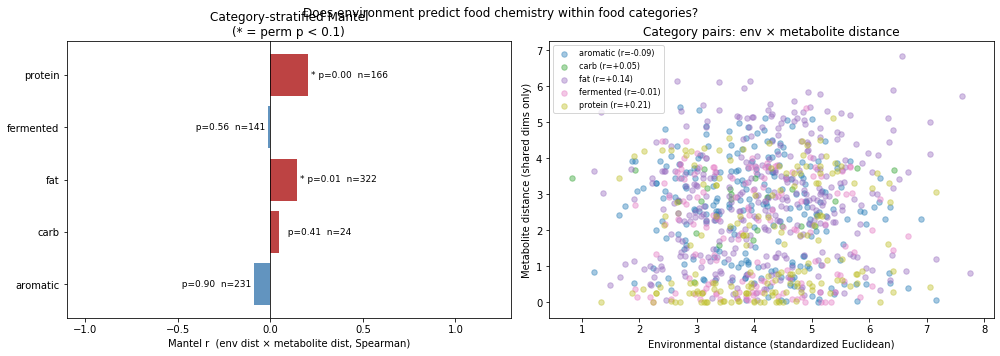

In [7]:
# Plot: Mantel r by food category
if len(cat_results_df) == 0:
    print("No categories with enough RSUs/pairs.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: bar chart of Mantel r per category
    ax = axes[0]
    colors = ['firebrick' if r > 0 else 'steelblue' for r in cat_results_df['mantel_r']]
    ax.barh(cat_results_df['category'], cat_results_df['mantel_r'], color=colors, alpha=0.85)
    for _, row in cat_results_df.iterrows():
        x = row['mantel_r']
        sig = '* ' if row['perm_p'] < 0.1 else '  '
        label = f"{sig}p={row['perm_p']:.2f}  n={row['n_pairs']}"
        ax.text(x + (0.015 if x >= 0 else -0.015), list(cat_results_df['category']).index(row['category']),
                label, va='center', ha='left' if x >= 0 else 'right', fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mantel r  (env dist × metabolite dist, Spearman)')
    ax.set_title('Category-stratified Mantel\n(* = perm p < 0.1)')
    ax.set_xlim(-1.1, 1.3)

    # Right: scatter for each category overlaid
    ax2 = axes[1]
    cmap = plt.cm.tab10
    for i, row in cat_results_df.iterrows():
        cat = row['category']
        cat_idx = [idx for idx, c in category_map.items() if c == cat]
        cat_matrix = food_matrix_full[food_matrix_full.index.isin(cat_idx)][geo_dims_all]
        cat_rsu = cat_matrix.groupby(level='region_id').mean()
        rsus_in_cat = [r for r in shared_rsus if r in cat_rsu.index]

        cat_pairs_plot = []
        for rsu_i, rsu_j in combinations(rsus_in_cat, 2):
            vec_i = cat_rsu.loc[rsu_i]
            vec_j = cat_rsu.loc[rsu_j]
            shared_mask = vec_i.notna() & vec_j.notna()
            if shared_mask.sum() < MIN_SHARED_CAT:
                continue
            shared_dims = list(shared_mask[shared_mask].index)
            sub = cat_rsu[shared_dims].dropna()
            if len(sub) < 2:
                continue
            sub_scaled = pd.DataFrame(
                StandardScaler().fit_transform(sub), index=sub.index, columns=shared_dims
            )
            met_d = float(np.linalg.norm(sub_scaled.loc[rsu_i].values - sub_scaled.loc[rsu_j].values))
            cat_pairs_plot.append({'env_dist': env_dist_df.loc[rsu_i, rsu_j], 'met_dist': met_d})

        if cat_pairs_plot:
            cp = pd.DataFrame(cat_pairs_plot)
            color = cmap(i / len(cat_results_df))
            ax2.scatter(cp['env_dist'], cp['met_dist'], alpha=0.4, s=30, color=color,
                        label=f"{cat} (r={row['mantel_r']:+.2f})")

    ax2.set_xlabel('Environmental distance (standardized Euclidean)')
    ax2.set_ylabel('Metabolite distance (shared dims only)')
    ax2.set_title('Category pairs: env × metabolite distance')
    ax2.legend(fontsize=8, loc='upper left')

    plt.suptitle('Does environment predict food chemistry within food categories?', fontsize=12)
    plt.tight_layout()
    plt.savefig('../data/metabolites/category_mantel.png', dpi=150, bbox_inches='tight')
    plt.show()

## Faceted terroir scatter — by category, min 4 shared dims

One plot per food category. No labels — points only. Filters to pairs with ≥ 4 shared
metabolite dimensions, removing low-confidence 2-dim pairs that inflate variance.

Fat and protein are the signal categories. Aromatic and fermented are expected noise.

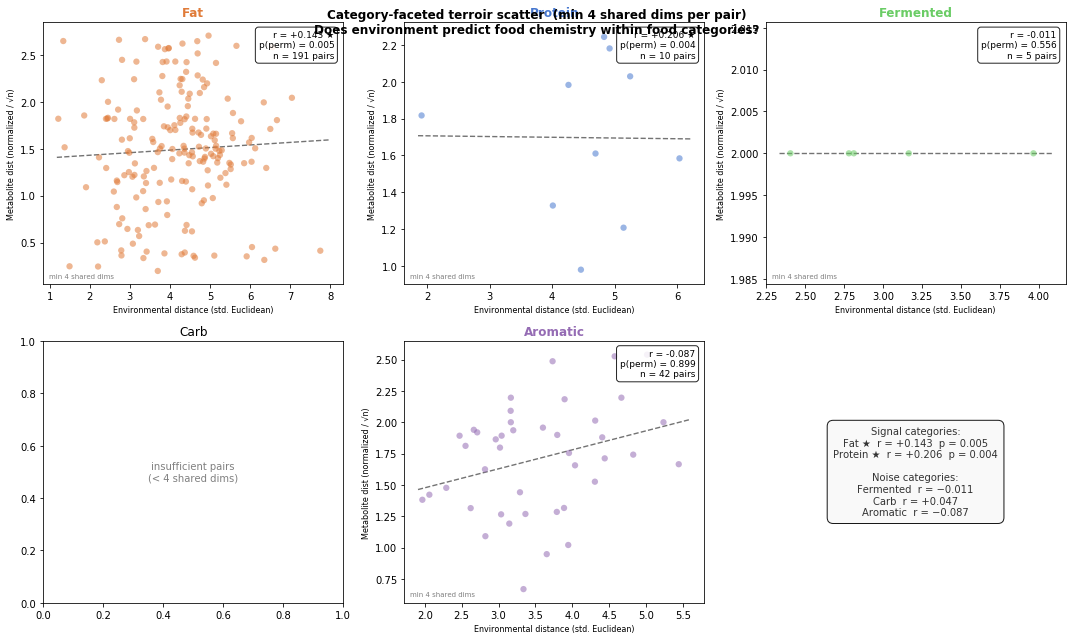


Pairs retained per category (min 4 shared dims):
  fat           191 pairs
  protein        10 pairs
  fermented       5 pairs
  carb            0 pairs
  aromatic       42 pairs


In [8]:
MIN_SCATTER_DIMS = 4

ordered_cats = ['fat', 'protein', 'fermented', 'carb', 'aromatic']
cat_colors = {
    'fat':       '#e07b39',
    'protein':   '#4878cf',
    'fermented': '#6acc65',
    'carb':      '#d65f5f',
    'aromatic':  '#956cb4',
}

# Collect pairs per category with MIN_SCATTER_DIMS filter
cat_pairs_facet = {}
for cat in ordered_cats:
    cat_idx = [idx for idx, c in category_map.items() if c == cat]
    cat_matrix = food_matrix_full[food_matrix_full.index.isin(cat_idx)][geo_dims_all]
    cat_rsu = cat_matrix.groupby(level='region_id').mean()
    rsus_in_cat = [r for r in shared_rsus if r in cat_rsu.index]

    pairs_list = []
    for rsu_i, rsu_j in combinations(rsus_in_cat, 2):
        vec_i = cat_rsu.loc[rsu_i]
        vec_j = cat_rsu.loc[rsu_j]
        shared_mask = vec_i.notna() & vec_j.notna()
        n_shared = shared_mask.sum()
        if n_shared < MIN_SCATTER_DIMS:
            continue
        shared_dims = list(shared_mask[shared_mask].index)
        sub = cat_rsu[shared_dims].dropna()
        if len(sub) < 2:
            continue
        sub_scaled = pd.DataFrame(
            StandardScaler().fit_transform(sub), index=sub.index, columns=shared_dims
        )
        raw_d = float(np.linalg.norm(
            sub_scaled.loc[rsu_i].values - sub_scaled.loc[rsu_j].values
        ))
        cat_pairs_facet.setdefault(cat, []).append({
            'rsu_i': rsu_i, 'rsu_j': rsu_j,
            'env_dist': env_dist_df.loc[rsu_i, rsu_j],
            'met_dist': raw_d / np.sqrt(n_shared),
            'n_shared': n_shared,
        })

cat_pairs_facet = {k: pd.DataFrame(v) for k, v in cat_pairs_facet.items()}

cr = cat_results_df.set_index('category') if len(cat_results_df) > 0 else pd.DataFrame()

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=False, sharey=False)
axes_flat = axes.flatten()

for i, cat in enumerate(ordered_cats):
    ax = axes_flat[i]
    df = cat_pairs_facet.get(cat, pd.DataFrame())
    color = cat_colors[cat]

    if df.empty:
        ax.text(0.5, 0.5, 'insufficient pairs\n(< 4 shared dims)',
                transform=ax.transAxes, ha='center', va='center', fontsize=10, color='gray')
        ax.set_title(cat.capitalize(), fontsize=12)
        continue

    # Scatter — no labels, semi-transparent
    ax.scatter(df['env_dist'], df['met_dist'],
               color=color, alpha=0.55, s=40, edgecolors='none', zorder=3)

    # Trend line
    if len(df) >= 3:
        coefs = np.polyfit(df['env_dist'], df['met_dist'], 1)
        x_range = np.linspace(df['env_dist'].min() * 0.97,
                              df['env_dist'].max() * 1.03, 100)
        ax.plot(x_range, np.polyval(coefs, x_range),
                color='black', lw=1.4, ls='--', alpha=0.55, zorder=2)

    # Stats annotation
    if cat in cr.index:
        r_val = cr.loc[cat, 'mantel_r']
        p_val = cr.loc[cat, 'perm_p']
        star = ' ★' if p_val < 0.1 else ''
        annot = f"r = {r_val:+.3f}{star}\np(perm) = {p_val:.3f}\nn = {len(df)} pairs"
        ax.text(0.97, 0.97, annot, transform=ax.transAxes,
                ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.35', facecolor='white', alpha=0.85))

    ax.set_title(cat.capitalize(), fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Environmental distance (std. Euclidean)', fontsize=8)
    ax.set_ylabel('Metabolite dist (normalized / √n)', fontsize=8)
    ax.text(0.02, 0.02, f'min {MIN_SCATTER_DIMS} shared dims',
            transform=ax.transAxes, fontsize=7, color='gray', va='bottom')

# Hide unused 6th panel
axes_flat[-1].axis('off')
axes_flat[-1].text(0.5, 0.5,
    'Signal categories:\nFat ★  r = +0.143  p = 0.005\nProtein ★  r = +0.206  p = 0.004\n\n'
    'Noise categories:\nFermented  r = −0.011\nCarb  r = +0.047\nAromatic  r = −0.087',
    transform=axes_flat[-1].transAxes, ha='center', va='center',
    fontsize=10, color='#333333',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f9f9f9', alpha=0.9))

plt.suptitle(
    f'Category-faceted terroir scatter  (min {MIN_SCATTER_DIMS} shared dims per pair)\n'
    'Does environment predict food chemistry within food categories?',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/metabolites/category_scatter_faceted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPairs retained per category (min {MIN_SCATTER_DIMS} shared dims):")
for cat in ordered_cats:
    df = cat_pairs_facet.get(cat, pd.DataFrame())
    print(f"  {cat:12s}  {len(df):3d} pairs")